In [15]:
#get Data
#get data from GitHub -> https://github.com/keuperj/DATA
!git clone https://github.com/keuperj/DATA.git

fatal: destination path 'DATA' already exists and is not an empty directory.


# Ex 1.2: A simple parallel MapReduce framework in Python
Now we use the [*multiprocessing*](https://docs.python.org/3/library/multiprocessing.html) lib to actually do things in parallel

Robin Adler 191845

In [30]:
import collections
import itertools
import multiprocessing


class SimpleMapReduce:

    def __init__(self, map_func, reduce_func, num_workers=None):
        """
        map_func

          Function to map inputs to intermediate data. Takes as
          argument one input value and returns a tuple with the
          key and a value to be reduced.

        reduce_func

          Function to reduce partitioned version of intermediate
          data to final output. Takes as argument a key as
          produced by map_func and a sequence of the values
          associated with that key.

        num_workers

          The number of workers to create in the pool. Defaults
          to the number of CPUs available on the current host.
        """
        self.map_func = map_func
        self.reduce_func = reduce_func
        self.pool = multiprocessing.Pool(num_workers)

    def partition(self, mapped_values):
        """Organize the mapped values by their key.
        Returns an unsorted sequence of tuples with a key
        and a sequence of values.
        """
        partitioned_data = collections.defaultdict(list)
        for key, value in mapped_values:
            partitioned_data[key].append(value)
        return partitioned_data.items()

    def __call__(self, inputs, chunksize=1):
        """Process the inputs through the map and reduce functions
        given.

        inputs
          An iterable containing the input data to be processed.

        chunksize=1
          The portion of the input data to hand to each worker.
          This can be used to tune performance during the mapping
          phase.
        """
        map_responses = self.pool.map(
            self.map_func,
            inputs,
            chunksize=chunksize,
        )
        partitioned_data = self.partition(
            itertools.chain(*map_responses)
        )
        reduced_values = self.pool.map(
            self.reduce_func,
            partitioned_data,
        )
        return reduced_values

### A Word Count example

In [17]:
import string

# map - read file and count words
def file_to_words(filename):
    """Read a file and return a sequence of
    (word, occurences) values.
    """
    STOP_WORDS = set([
        'a', 'an', 'and', 'are', 'as', 'be', 'by', 'for', 'if',
        'in', 'is', 'it', 'of', 'or', 'py', 'rst', 'that', 'the',
        'to', 'with',
    ])
    TR = str.maketrans({
        p: ' '
        for p in string.punctuation
    })

    print('{} reading {}'.format(
        multiprocessing.current_process().name, filename))
    output = []

    with open(filename, 'rt') as f:
        for line in f:
            # Skip comment lines.
            if line.lstrip().startswith('..'):
                continue
            line = line.translate(TR)  # Strip punctuation
            for word in line.split():
                word = word.lower()
                if word.isalpha() and word not in STOP_WORDS:
                    output.append((word, 1))
    return output

# reduce
def count_words(item):
    """Convert the partitioned data for a word to a
    tuple containing the word and the number of occurences.
    """
    word, occurences = item
    return (word, sum(occurences))

In [18]:
import operator
import glob #easy file access

input_files = glob.glob('DATA/*.rst')#get all text files names

mapper = SimpleMapReduce(file_to_words, count_words)#get mapreduce instance with custom map and reduce functions
word_counts = mapper(input_files)#call parallel mapreduce on files

word_counts.sort(key=operator.itemgetter(1))#sort results
word_counts.reverse()

print('\nTOP 20 WORDS BY FREQUENCY\n')
top20 = word_counts[:20]
longest = max(len(word) for word, count in top20)
for word, count in top20:
    print('{word:<{len}}: {count:5}'.format(
            len=longest + 1,
            word=word,
            count=count)
    )

ForkPoolWorker-16 reading DATA/text1.rstForkPoolWorker-15 reading DATA/text2.rst

ForkPoolWorker-15 reading DATA/text3.rst
ForkPoolWorker-16 reading DATA/text4.rst

TOP 20 WORDS BY FREQUENCY

my    :    67
i     :    60
her   :    43
he    :    41
quiz  :    33
quick :    28
was   :    28
his   :    23
fox   :    22
she   :    21
from  :    20
when  :    20
blind :    19
vex   :    18
have  :    18
would :    18
but   :    18
so    :    18
on    :    17
big   :    16


## K-Means implementation
Use the simple frame work to implement K-Means

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

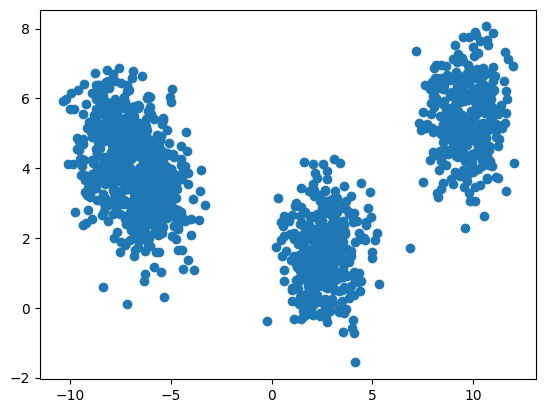

In [20]:
#generate data with K=4
X, y = make_blobs(n_samples=1500, centers=4)
plt.scatter(X[:, 0], X[:, 1])

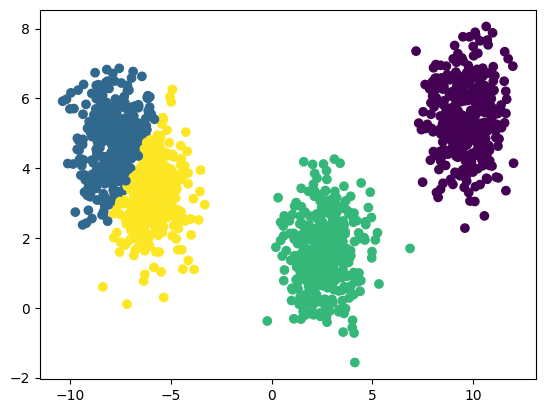

In [21]:
#K-Means ref implementation
k = KMeans(n_clusters=4, random_state=42)
y_pred = k.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)

In [22]:
k.cluster_centers_

array([[ 9.72851704,  5.47548763],
       [-7.87305412,  4.77303817],
       [ 2.61414435,  1.59603981],
       [-5.86071829,  3.18989894]])

In [23]:
def kMap(p):
    #p is one Point
    distances = [np.linalg.norm(p - c) for c in center]
    nearest_index = np.argmin(distances)
    return [(nearest_index, p)]

In [24]:
def kReduce(item):
    cluster_index, points = item
    new_center = np.mean(points, axis=0)
    return new_center

In [25]:
#init centers
#4 Clusters
center = X[np.random.randint(X.shape[0], size=4), :]
print('init center', center)

init center [[ 8.0122202   5.04537596]
 [10.96703243  7.88052063]
 [ 2.97870618  2.63237027]
 [-6.56391019  2.47110067]]


In [26]:
#use framework
mapper = SimpleMapReduce(kMap, kReduce)#get mapreduce instance with custom map and reduce functions
center = mapper(X)#call parallel mapreduce oo data

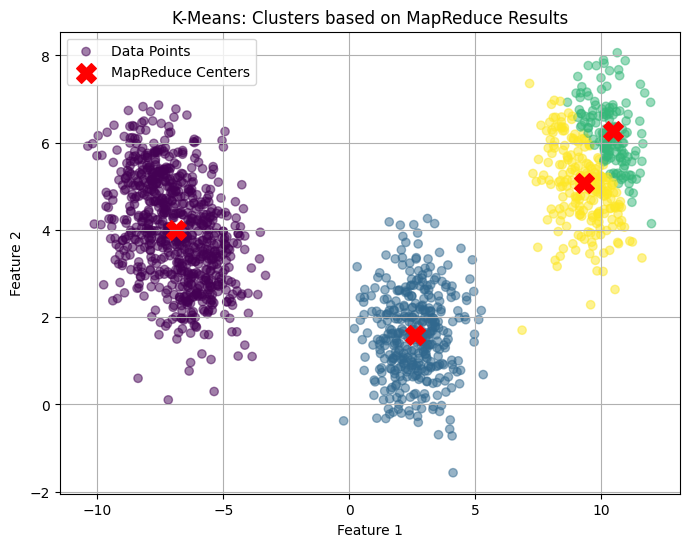

In [27]:
import numpy as np
import matplotlib.pyplot as plt

centers_array = np.array(center)

#Calculate assignments based on the MapReduce centers
#For each point in X, find the index of the closest center in centers_array
y_mapreduce = np.array([np.argmin([np.linalg.norm(p - c) for c in centers_array]) for p in X])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_mapreduce, alpha=0.5, cmap='viridis', label='Data Points')
plt.scatter(centers_array[:, 0], centers_array[:, 1], c='red', marker='X', s=200, label='MapReduce Centers')

plt.title('K-Means: Clusters based on MapReduce Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Iterating 5 Steps

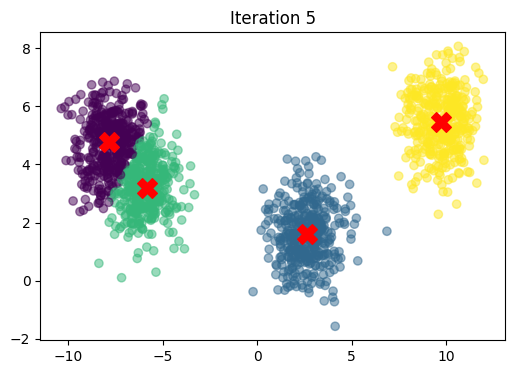

In [28]:
center = X[np.random.randint(X.shape[0], size=4), :]

for i in range(5):
    mapper = SimpleMapReduce(kMap, kReduce)
    center = mapper(X)
    centers_array = np.array(center)

y_mapreduce = np.array([np.argmin([np.linalg.norm(p - c) for c in centers_array]) for p in X])
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_mapreduce, alpha=0.5, cmap='viridis')
plt.scatter(centers_array[:, 0], centers_array[:, 1], c='red', marker='X', s=200)
plt.title(f'Iteration {i+1}')
plt.show()